# Week 5 - Survival Analysis (Weibull and Cox Models)

In [1]:
import sys
sys.path.append('../src')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, CoxPHFitter
from lifelines.utils import median_survival_times
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from data_loader import CMAPSSLoader
from preprocessor import CMAPSSPreprocessor

In [2]:
# Load models from week 3 and 4
lr_model = joblib.load('../data/models/cmapss/lr_model.pkl')
ridge_model = joblib.load('../data/models/cmapss/ridge_model.pkl')
lasso_model = joblib.load('../data/models/cmapss/lasso_model.pkl')
rf_model = joblib.load('../data/models/cmapss/rf_model.pkl')
gb_model = joblib.load('../data/models/cmapss/gb_model.pkl')
print("Models loaded successfully")

Models loaded successfully


In [3]:
# Load cleaned and featured data
df = pd.read_csv('../data/gold/cmapss/FD001_top_features.csv')
print(f"Data shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

Data shape: (20631, 24)

First few rows:
   engine_id  time_cycles  RUL  RUL_clipped  sensor_4_rolling_mean_5  \
0          1            1  191          125                 0.289887   
1          1            2  190          125                 0.317735   
2          1            3  189          125                 0.334766   
3          1            4  188          125                 0.330508   
4          1            5  187          125                 0.347031   

   sensor_7_rolling_mean_5  sensor_17_rolling_mean_5  \
0                 0.778509                  0.263158   
1                 0.711623                  0.263158   
2                 0.726608                  0.175439   
3                 0.744518                  0.197368   
4                 0.735526                  0.236842   

   sensor_20_rolling_mean_5  sensor_11_lag_1  sensor_9  ...  \
0                  0.777542         0.380368  0.109755  ...   
1                  0.745763         0.380368  0.100242  ...   


In [4]:
np.random.seed(42)

# Aggregate to engine level (one row per engine at failure)
df_engines = df.groupby('engine_id').agg({
    'time_cycles': 'max',  # Time to failure (when RUL = 0)
    'RUL': 'min',  # Should be 0 or close to 0
    'RUL_clipped': 'min'
}).reset_index()

# Add features for each engine (final sensor values + degradation)
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

for sensor in sensor_cols:
    # Final value at failure
    df_engines[f'{sensor}_final'] = df.groupby('engine_id')[sensor].last().values
    # Mean across lifecycle
    df_engines[f'{sensor}_mean'] = df.groupby('engine_id')[sensor].mean().values
    # Degradation (final - first)
    df_engines[f'{sensor}_degradation'] = (
        df.groupby('engine_id')[sensor].last().values - 
        df.groupby('engine_id')[sensor].first().values
    )

# Survival data: duration = time_cycles to failure, event = 1 (all fail)
df_engines['duration'] = df_engines['time_cycles']
df_engines['event'] = 1  # All engines failed

print(f"Engines: {len(df_engines)}")
print(f"Time to failure (mean): {df_engines['duration'].mean():.0f} cycles")
print(f"Time to failure (range): {df_engines['duration'].min():.0f} - {df_engines['duration'].max():.0f} cycles")
print(f"Event rate: {df_engines['event'].mean():.0%} (all engines failed)")

feature_cols = [col for col in df_engines.columns if col.endswith('_final')]

model_data = df_engines[feature_cols + ['duration', 'event']].copy()

print(f"\nFeatures used: {len(feature_cols)} final sensor values")
print(f"Model data shape: {model_data.shape}")


Engines: 100
Time to failure (mean): 206 cycles
Time to failure (range): 128 - 362 cycles
Event rate: 100% (all engines failed)

Features used: 20 final sensor values
Model data shape: (100, 22)


## 1. Weibull Accelerated Failure Time Model

In [5]:
waft = WeibullAFTFitter(penalizer=0.1)
waft.fit(model_data, duration_col='duration', event_col='event')
print(waft.summary)

                                            coef  exp(coef)  se(coef)  \
param   covariate                                                       
lambda_ sensor_11_final                -0.472650   0.623348  0.296882   
        sensor_11_lag_1_final          -0.159771   0.852339  0.274525   
        sensor_12_lag_1_final           0.534565   1.706705  0.233267   
        sensor_15_rolling_mean_5_final -0.663439   0.515077  0.497239   
        sensor_15_rolling_min_10_final  0.846156   2.330671  0.276152   
        sensor_17_rolling_max_10_final  0.346522   1.414140  0.400039   
        sensor_17_rolling_mean_5_final  0.030582   1.031054  0.419247   
        sensor_20_rolling_mean_5_final -0.046816   0.954263  0.511894   
        sensor_20_rolling_min_10_final  0.659250   1.933342  0.457100   
        sensor_21_rolling_max_10_final -0.596452   0.550762  0.328622   
        sensor_21_rolling_mean_5_final  0.157421   1.170489  0.471859   
        sensor_21_rolling_min_10_final  0.309247   

## 2. COX Proportional Hazards Model

In [6]:
cox_data = df_engines[feature_cols + ['duration', 'event']].copy()

# Standardize features for Cox
scaler = StandardScaler()
cox_data[feature_cols] = scaler.fit_transform(cox_data[feature_cols])

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='duration', event_col='event')
print(cph.summary)


                                    coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                                       
sensor_4_rolling_mean_5_final  -0.041452   0.959395  0.118839       -0.274373   
sensor_7_rolling_mean_5_final  -0.093818   0.910449  0.145020       -0.378052   
sensor_17_rolling_mean_5_final -0.045159   0.955846  0.150254       -0.339651   
sensor_20_rolling_mean_5_final  0.009814   1.009863  0.128179       -0.241412   
sensor_11_lag_1_final           0.041963   1.042856  0.099858       -0.153755   
sensor_9_final                 -0.484223   0.616176  0.202852       -0.881805   
sensor_15_rolling_mean_5_final  0.109991   1.116268  0.104192       -0.094221   
sensor_21_rolling_mean_5_final -0.069817   0.932565  0.129895       -0.324407   
sensor_17_rolling_max_10_final -0.040824   0.959998  0.149696       -0.334222   
sensor_2_rolling_mean_5_final  -0.079052   0.923992  0.110555       -0.295736   
sensor_21_rolling_min_10_fin

---
# Results
## Survival curves

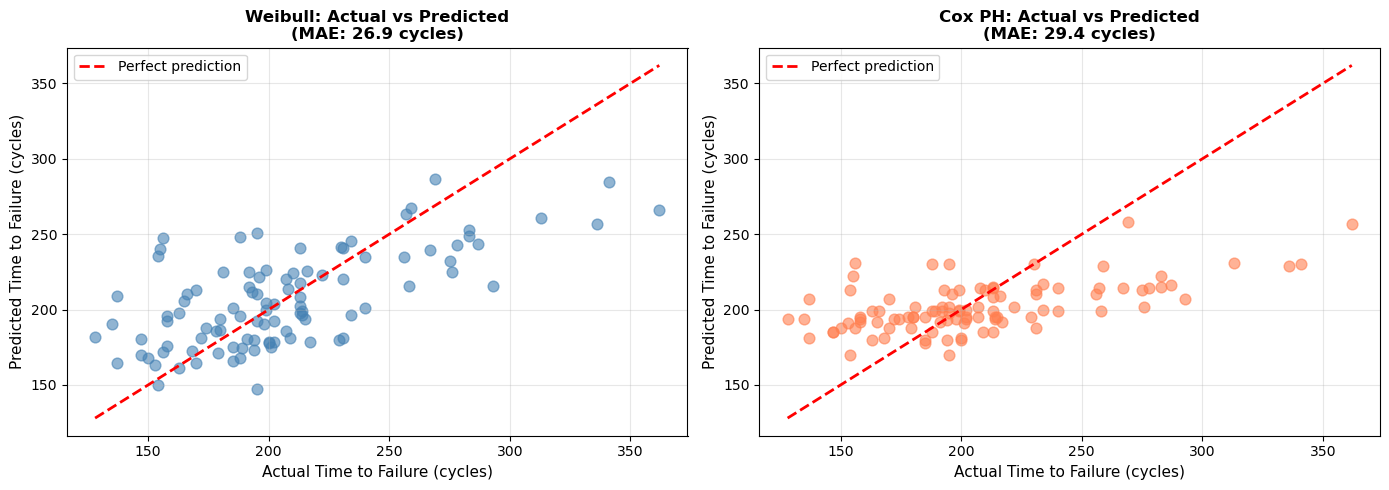

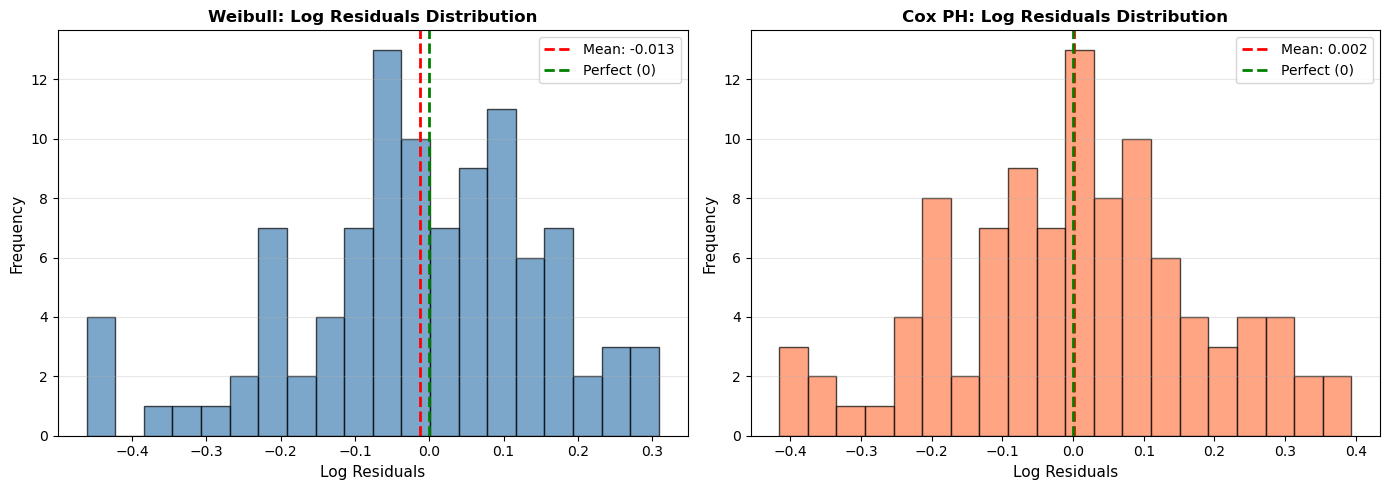

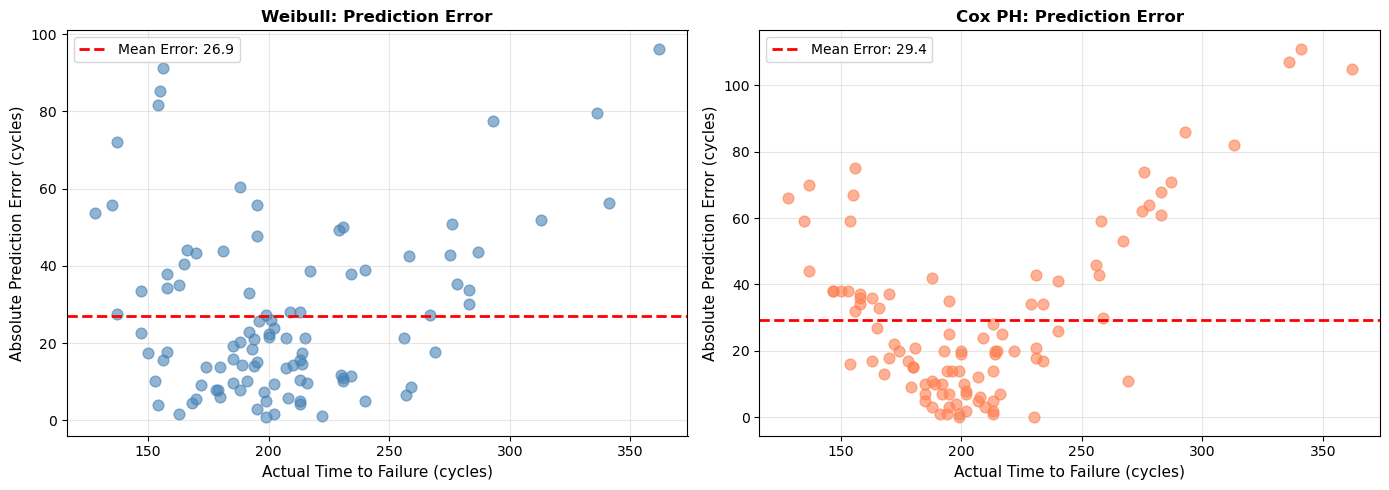

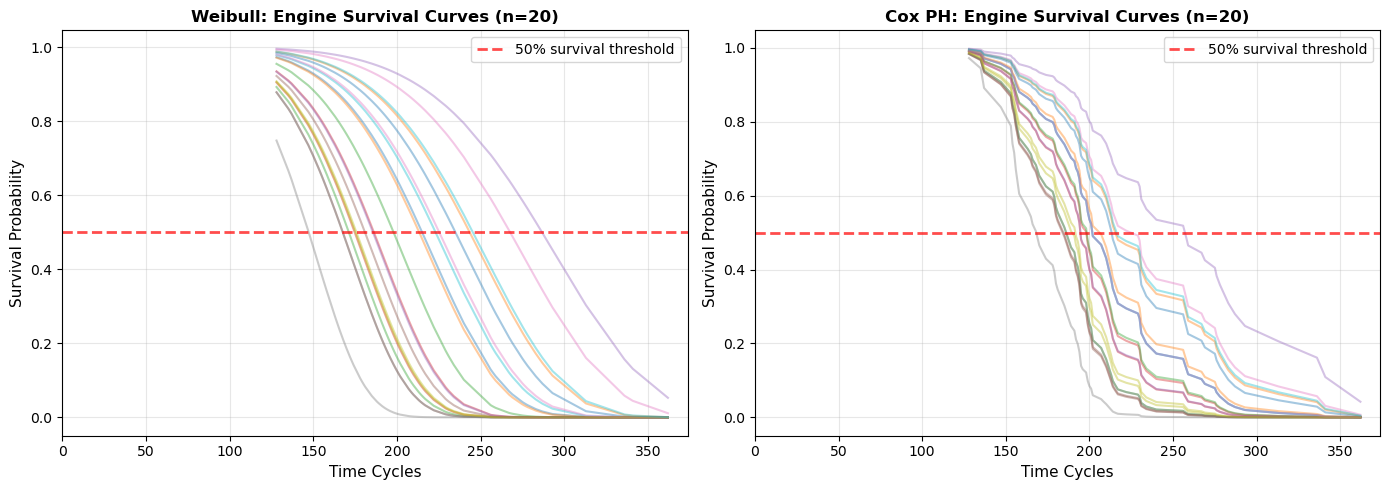

In [7]:
# Actual vs Predicted Time to Failure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weibull
ax = axes[0]
waft_pred = waft.predict_median(model_data)
ax.scatter(model_data['duration'], waft_pred, alpha=0.6, s=60, color='steelblue')
ax.plot([model_data['duration'].min(), model_data['duration'].max()],
        [model_data['duration'].min(), model_data['duration'].max()],
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Time to Failure (cycles)', fontsize=11)
ax.set_ylabel('Predicted Time to Failure (cycles)', fontsize=11)
ax.set_title(f'Weibull: Actual vs Predicted\n(MAE: {np.abs(model_data["duration"] - waft_pred).mean():.1f} cycles)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Cox
ax = axes[1]
cox_pred = cph.predict_median(cox_data)
ax.scatter(cox_data['duration'], cox_pred, alpha=0.6, s=60, color='coral')
ax.plot([cox_data['duration'].min(), cox_data['duration'].max()],
        [cox_data['duration'].min(), cox_data['duration'].max()],
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Time to Failure (cycles)', fontsize=11)
ax.set_ylabel('Predicted Time to Failure (cycles)', fontsize=11)
ax.set_title(f'Cox PH: Actual vs Predicted\n(MAE: {np.abs(cox_data["duration"] - cox_pred).mean():.1f} cycles)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Residuals Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weibull residuals
ax = axes[0]
waft_residuals = np.log(model_data['duration']) - np.log(waft_pred)
ax.hist(waft_residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(waft_residuals.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {waft_residuals.mean():.3f}')
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect (0)')
ax.set_xlabel('Log Residuals', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Weibull: Log Residuals Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Cox residuals
ax = axes[1]
cox_residuals = np.log(cox_data['duration']) - np.log(cox_pred)
ax.hist(cox_residuals, bins=20, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(cox_residuals.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {cox_residuals.mean():.3f}')
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect (0)')
ax.set_xlabel('Log Residuals', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Cox PH: Log Residuals Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# Prediction Error by Time to Failure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weibull
ax = axes[0]
waft_error = np.abs(model_data['duration'] - waft_pred)
ax.scatter(model_data['duration'], waft_error, alpha=0.6, s=60, color='steelblue')
ax.axhline(waft_error.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean Error: {waft_error.mean():.1f}')
ax.set_xlabel('Actual Time to Failure (cycles)', fontsize=11)
ax.set_ylabel('Absolute Prediction Error (cycles)', fontsize=11)
ax.set_title('Weibull: Prediction Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Cox
ax = axes[1]
cox_error = np.abs(cox_data['duration'] - cox_pred)
ax.scatter(cox_data['duration'], cox_error, alpha=0.6, s=60, color='coral')
ax.axhline(cox_error.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean Error: {cox_error.mean():.1f}')
ax.set_xlabel('Actual Time to Failure (cycles)', fontsize=11)
ax.set_ylabel('Absolute Prediction Error (cycles)', fontsize=11)
ax.set_title('Cox PH: Prediction Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Survival Curves (Sample of 20 Engines)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weibull survival curves
ax = axes[0]
waft_survival = waft.predict_survival_function(model_data)
for idx in range(min(20, len(model_data))):
    ax.plot(waft_survival.index, waft_survival.iloc[:, idx], alpha=0.4, linewidth=1.5)
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, alpha=0.7, label='50% survival threshold')
ax.set_xlabel('Time Cycles', fontsize=11)
ax.set_ylabel('Survival Probability', fontsize=11)
ax.set_title('Weibull: Engine Survival Curves (n=20)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(left=0)

# Cox survival curves
ax = axes[1]
cox_survival = cph.predict_survival_function(cox_data)
for idx in range(min(20, len(cox_data))):
    if idx < len(cox_survival.columns):
        ax.plot(cox_survival.index, cox_survival.iloc[:, idx], alpha=0.4, linewidth=1.5)
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, alpha=0.7, label='50% survival threshold')
ax.set_xlabel('Time Cycles', fontsize=11)
ax.set_ylabel('Survival Probability', fontsize=11)
ax.set_title('Cox PH: Engine Survival Curves (n=20)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## Summary

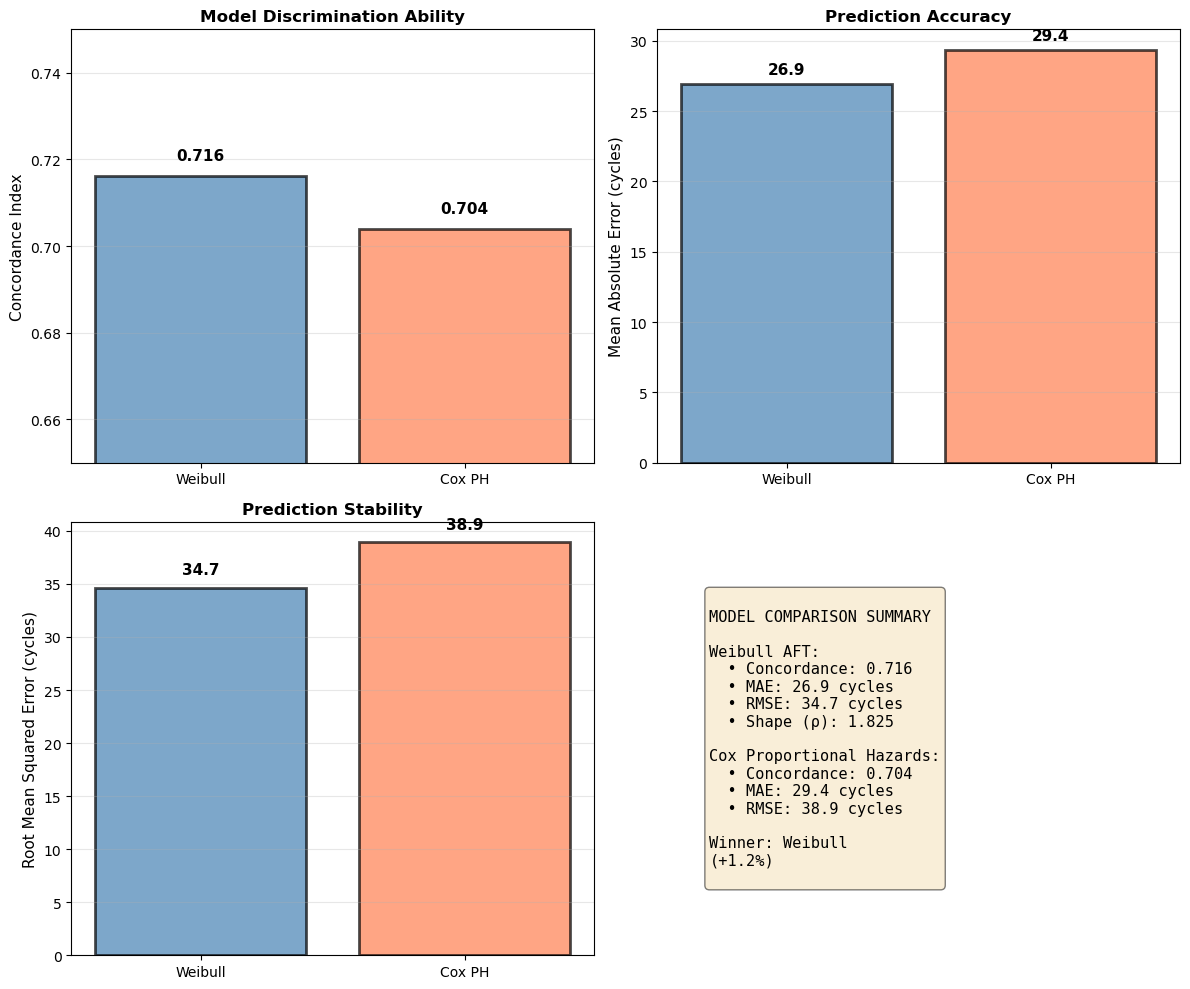

In [8]:
# Model Performance Summary
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Concordance comparison
ax = axes[0, 0]
models = ['Weibull', 'Cox PH']
concordances = [waft.concordance_index_, cph.concordance_index_]
bars = ax.bar(models, concordances, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Concordance Index', fontsize=11)
ax.set_title('Model Discrimination Ability', fontsize=12, fontweight='bold')
ax.set_ylim([0.65, 0.75])
for i, (bar, val) in enumerate(zip(bars, concordances)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# MAE comparison
ax = axes[0, 1]
mae_weibull = np.abs(model_data['duration'] - waft_pred).mean()
mae_cox = np.abs(cox_data['duration'] - cox_pred).mean()
maes = [mae_weibull, mae_cox]
bars = ax.bar(models, maes, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Mean Absolute Error (cycles)', fontsize=11)
ax.set_title('Prediction Accuracy', fontsize=12, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, maes)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# RMSE comparison
ax = axes[1, 0]
rmse_weibull = np.sqrt(np.mean((model_data['duration'] - waft_pred)**2))
rmse_cox = np.sqrt(np.mean((cox_data['duration'] - cox_pred)**2))
rmses = [rmse_weibull, rmse_cox]
bars = ax.bar(models, rmses, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Root Mean Squared Error (cycles)', fontsize=11)
ax.set_title('Prediction Stability', fontsize=12, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, rmses)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Summary text
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
MODEL COMPARISON SUMMARY

Weibull AFT:
  • Concordance: {waft.concordance_index_:.3f}
  • MAE: {mae_weibull:.1f} cycles
  • RMSE: {rmse_weibull:.1f} cycles
  • Shape (ρ): {waft.params_['rho_', 'Intercept']:.3f}

Cox Proportional Hazards:
  • Concordance: {cph.concordance_index_:.3f}
  • MAE: {mae_cox:.1f} cycles
  • RMSE: {rmse_cox:.1f} cycles

Winner: {'Weibull' if waft.concordance_index_ > cph.concordance_index_ else 'Cox PH'}
(+{abs(waft.concordance_index_ - cph.concordance_index_):.1%})
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [9]:
# Save different models for reuse

# Create directory if it doesn't exist
os.makedirs('../data/models/cmapss/', exist_ok=True)

joblib.dump(waft, '../data/models/cmapss/waft.pkl')
joblib.dump(cph, '../data/models/cmapss/cph.pkl')

print("All models saved successfully!")

All models saved successfully!
